In [16]:
import numpy as np

# Load the route grids and corresponding grades
climbs_raw = np.loadtxt("../data/climbs.txt", dtype=np.float32)
grades = np.loadtxt("../data/grades.txt", dtype=np.float32)

print("Raw climbs shape:", climbs_raw.shape)
print("Grades shape:", grades.shape)

Raw climbs shape: (214308, 11)
Grades shape: (11906,)


In [17]:
number_of_routes = len(grades)
climbs = climbs_raw.reshape(number_of_routes, 18, 11)

In [18]:
assert climbs.shape[0] == grades.shape[0]
assert climbs.shape[1:] == (18, 11)
assert np.all(np.isin(climbs, [0, 1]))

print("Number of routes:", len(climbs))
print("Board dimensions:", climbs.shape[1:])
print("Minimum grade:", grades.min())
print("Maximum grade:", grades.max())
print("Dataset loaded successfully.")

Number of routes: 11906
Board dimensions: (18, 11)
Minimum grade: 0.0
Maximum grade: 16.0
Dataset loaded successfully.


## Data Cleaning

The dataset contains one route labeled V0, which is likely invalid or mislabeled, so it is removed. Duplicate routes with identical hold layouts are also removed to prevent the same climb from appearing multiple times in the dataset.

In [19]:
# Remove the V0 route because it is likely invalid or mislabeled

valid_routes = grades != 0

X = climbs[valid_routes]
y = grades[valid_routes]

print("Routes before removing V0:", len(grades))
print("Routes removed:", len(grades) - len(y))
print("Routes remaining:", len(y))
print("Remaining grades:", np.unique(y))

Routes before removing V0: 11906
Routes removed: 1
Routes remaining: 11905
Remaining grades: [ 4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16.]


In [20]:
# Flatten each 18 x 11 route into one row of 198 values

X_flat = X.reshape(X.shape[0], -1)

print("Original route shape:", X.shape)
print("Flattened route shape:", X_flat.shape)

Original route shape: (11905, 18, 11)
Flattened route shape: (11905, 198)


In [21]:
# Find the first occurrence of every unique board layout

_, unique_indices = np.unique(
    X_flat,
    axis=0,
    return_index=True
)

# Sort the indices so routes remain in their original order
unique_indices = np.sort(unique_indices)

X_clean = X[unique_indices]
y_clean = y[unique_indices]

print("Routes before duplicate removal:", len(X))
print("Clean routes:", len(X_clean))
print("Duplicates removed:", len(X) - len(X_clean))

print("\nClean route shape:", X_clean.shape)
print("Clean grade shape:", y_clean.shape)

Routes before duplicate removal: 11905
Clean routes: 11736
Duplicates removed: 169

Clean route shape: (11736, 18, 11)
Clean grade shape: (11736,)


In [22]:
assert X_clean.shape[0] == y_clean.shape[0]
assert X_clean.shape[1:] == (18, 11)
assert 0 not in y_clean
assert len(np.unique(X_clean.reshape(len(X_clean), -1), axis=0)) == len(X_clean)

print("Cleaning checks passed.")
print("Final number of routes:", len(X_clean))
print("Final input shape:", X_clean.shape)
print("Final target shape:", y_clean.shape)

Cleaning checks passed.
Final number of routes: 11736
Final input shape: (11736, 18, 11)
Final target shape: (11736,)


## Train, Validation, and Test Split

The cleaned dataset is divided into training, validation, and test sets.

- The training set is used to update the neural network's weights.
- The validation set is used to monitor performance during development.
- The test set is held back until the final evaluation.

In [23]:
from sklearn.model_selection import train_test_split

# First split: 80% training, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X_clean,
    y_clean,
    test_size=0.20,
    random_state=42,
    stratify=y_clean
)

# Second split: divide the temporary set equally
# Final split = 80% training, 10% validation, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training inputs:", X_train.shape)
print("Training targets:", y_train.shape)

print("\nValidation inputs:", X_val.shape)
print("Validation targets:", y_val.shape)

print("\nTest inputs:", X_test.shape)
print("Test targets:", y_test.shape)

Training inputs: (9388, 18, 11)
Training targets: (9388,)

Validation inputs: (1174, 18, 11)
Validation targets: (1174,)

Test inputs: (1174, 18, 11)
Test targets: (1174,)


In [24]:
# Validate the split

total_split_routes = len(X_train) + len(X_val) + len(X_test)

assert total_split_routes == len(X_clean)
assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

print("Total cleaned routes:", len(X_clean))
print("Total routes after splitting:", total_split_routes)

print("\nTraining percentage:", len(X_train) / len(X_clean))
print("Validation percentage:", len(X_val) / len(X_clean))
print("Test percentage:", len(X_test) / len(X_clean))

print("\nData split checks passed.")

Total cleaned routes: 11736
Total routes after splitting: 11736

Training percentage: 0.799931833674165
Validation percentage: 0.10003408316291752
Test percentage: 0.10003408316291752

Data split checks passed.


## Convert the Data to PyTorch Tensors

PyTorch models use tensors instead of NumPy arrays. The route grids and grade labels are converted to 32-bit floating-point tensors before they are passed into the neural network.m

In [25]:
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

/Users/tadhgsheeran/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
# Inspect the tensors

print("Training input type:", type(X_train_tensor))
print("Training input data type:", X_train_tensor.dtype)
print("Training input shape:", X_train_tensor.shape)

print("\nTraining target type:", type(y_train_tensor))
print("Training target data type:", y_train_tensor.dtype)
print("Training target shape:", y_train_tensor.shape)

Training input type: <class 'torch.Tensor'>
Training input data type: torch.float32
Training input shape: torch.Size([9388, 18, 11])

Training target type: <class 'torch.Tensor'>
Training target data type: torch.float32
Training target shape: torch.Size([9388])


In [27]:
# Inspect one route

print("First training route:")
print(X_train_tensor[0])

print("\nRoute shape:", X_train_tensor[0].shape)
print("Route grade:", y_train_tensor[0])

First training route:
tensor([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

Rout

In [28]:
# Validate the conversion

assert X_train_tensor.shape == X_train.shape
assert X_val_tensor.shape == X_val.shape
assert X_test_tensor.shape == X_test.shape

assert y_train_tensor.shape == y_train.shape
assert y_val_tensor.shape == y_val.shape
assert y_test_tensor.shape == y_test.shape

assert X_train_tensor.dtype == torch.float32
assert y_train_tensor.dtype == torch.float32

print("Tensor conversion checks passed.")

Tensor conversion checks passed.


## Create PyTorch Datasets and DataLoaders

A PyTorch Dataset stores the input routes and corresponding grades together. A DataLoader divides the dataset into smaller batches and supplies those batches to the model during training and evaluation.

In [29]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

print("Training examples:", len(train_dataset))
print("Validation examples:", len(val_dataset))
print("Test examples:", len(test_dataset))

Training examples: 9388
Validation examples: 1174
Test examples: 1174


In [30]:
# Create the DataLoaders

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [31]:
# Inspect one batch

route_batch, grade_batch = next(iter(train_loader))

print("Route batch shape:", route_batch.shape)
print("Grade batch shape:", grade_batch.shape)

print("\nFirst grade in batch:", grade_batch[0])
print("First route shape:", route_batch[0].shape)

Route batch shape: torch.Size([32, 18, 11])
Grade batch shape: torch.Size([32])

First grade in batch: tensor(12.)
First route shape: torch.Size([18, 11])


In [32]:
# Check the number of batches

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 294
Validation batches: 37
Test batches: 37


In [33]:
# Final Checks

assert len(train_dataset) == len(X_train_tensor)
assert len(val_dataset) == len(X_val_tensor)
assert len(test_dataset) == len(X_test_tensor)

assert route_batch.ndim == 3
assert route_batch.shape[1:] == (18, 11)
assert grade_batch.ndim == 1

print("Dataset and DataLoader checks passed.")

Dataset and DataLoader checks passed.


## Define the Neural Network

The model is a multilayer perceptron, or MLP. Each MoonBoard route begins as an 18 × 11 grid and is flattened into 198 input values. The model passes those values through several fully connected layers and produces one numerical grade prediction.

In [34]:
import torch.nn as nn


class MoonBoardMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(18 * 11, 128),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        predictions = self.network(x)

        return predictions.squeeze(1)

In [35]:
# Create the model

model = MoonBoardMLP()

print(model)

MoonBoardMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=198, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=64, out_features=32, bias=True)
    (8): ReLU()
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [36]:
# Test a forward pass

route_batch, grade_batch = next(iter(train_loader))

with torch.no_grad():
    prediction_batch = model(route_batch)

print("Input batch shape:", route_batch.shape)
print("Prediction batch shape:", prediction_batch.shape)
print("Target batch shape:", grade_batch.shape)

print("\nFirst five untrained predictions:")
print(prediction_batch[:5])

print("\nFirst five actual grades:")
print(grade_batch[:5])

Input batch shape: torch.Size([32, 18, 11])
Prediction batch shape: torch.Size([32])
Target batch shape: torch.Size([32])

First five untrained predictions:
tensor([0.1653, 0.1609, 0.1593, 0.1562, 0.1581])

First five actual grades:
tensor([8., 5., 8., 4., 8.])


In [37]:
# Final Check

assert prediction_batch.shape == grade_batch.shape
assert prediction_batch.ndim == 1

print("Model architecture and forward-pass checks passed.")

Model architecture and forward-pass checks passed.


## Configure Model Training

The model is assigned to the best available computing device. A loss function measures prediction error, and an optimizer updates the model's weights to reduce that error.

In [38]:
# Select the device

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model = MoonBoardMLP().to(device)

print("Using device:", device)

Using device: cpu


In [39]:
# Define the loss function

criterion = nn.SmoothL1Loss()

print("Loss function:", criterion)

Loss function: SmoothL1Loss()


In [40]:
# Define the optimizer

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    eps: 1e-08
    foreach: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [41]:
# Count the model parameters

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Total parameters:", total_parameters)
print("Trainable parameters:", trainable_parameters)

Total parameters: 35841
Trainable parameters: 35841


In [42]:
# Test one batch on the selected device

route_batch, grade_batch = next(iter(train_loader))

route_batch = route_batch.to(device)
grade_batch = grade_batch.to(device)

model.eval()

with torch.no_grad():
    prediction_batch = model(route_batch)
    loss = criterion(prediction_batch, grade_batch)

print("Route device:", route_batch.device)
print("Grade device:", grade_batch.device)
print("Prediction device:", prediction_batch.device)

print("\nPrediction shape:", prediction_batch.shape)
print("Target shape:", grade_batch.shape)
print("Untrained batch loss:", loss.item())

Route device: cpu
Grade device: cpu
Prediction device: cpu

Prediction shape: torch.Size([32])
Target shape: torch.Size([32])
Untrained batch loss: 6.20058536529541


In [43]:
# Final checks

assert prediction_batch.shape == grade_batch.shape
assert prediction_batch.device == grade_batch.device
assert next(model.parameters()).device == route_batch.device

print("Training configuration checks passed.")

Training configuration checks passed.


## Train the Neural Network

During training, the model processes one batch at a time. For each batch, it makes predictions, measures the error, calculates gradients, and updates its weights.

In [44]:
model.train()

running_loss = 0.0

for route_batch, grade_batch in train_loader:
    route_batch = route_batch.to(device)
    grade_batch = grade_batch.to(device)

    optimizer.zero_grad()

    predictions = model(route_batch)

    loss = criterion(predictions, grade_batch)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

average_training_loss = running_loss / len(train_loader)

print("Average training loss:", average_training_loss)

Average training loss: 1.8924033639787816


In [45]:
# Add validation

model.eval()

validation_loss = 0.0

with torch.no_grad():
    for route_batch, grade_batch in val_loader:
        route_batch = route_batch.to(device)
        grade_batch = grade_batch.to(device)

        predictions = model(route_batch)

        loss = criterion(predictions, grade_batch)

        validation_loss += loss.item()

average_validation_loss = validation_loss / len(val_loader)

print("Average training loss:", average_training_loss)
print("Average validation loss:", average_validation_loss)

Average training loss: 1.8924033639787816
Average validation loss: 1.0948143214792818


## Full Model Training

The model is trained over multiple epochs. Training and validation loss are recorded after each epoch so learning progress and potential overfitting can be monitored.

In [46]:
# Reset the model so the full experiment starts from new random weights

torch.manual_seed(42)

model = MoonBoardMLP().to(device)

criterion = nn.SmoothL1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [47]:
# Create the training history

num_epochs = 30

training_losses = []
validation_losses = []

for epoch in range(num_epochs):

    
# Training phase
    
    model.train()

    total_training_loss = 0.0

    for route_batch, grade_batch in train_loader:
        route_batch = route_batch.to(device)
        grade_batch = grade_batch.to(device)

        optimizer.zero_grad()

        predictions = model(route_batch)

        loss = criterion(predictions, grade_batch)

        loss.backward()

        optimizer.step()

        total_training_loss += loss.item()

    average_training_loss = (
        total_training_loss / len(train_loader)
    )

    
# Validation phase
    
    model.eval()

    total_validation_loss = 0.0

    with torch.no_grad():
        for route_batch, grade_batch in val_loader:
            route_batch = route_batch.to(device)
            grade_batch = grade_batch.to(device)

            predictions = model(route_batch)

            loss = criterion(predictions, grade_batch)

            total_validation_loss += loss.item()

    average_validation_loss = (
        total_validation_loss / len(val_loader)
    )

    training_losses.append(average_training_loss)
    validation_losses.append(average_validation_loss)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Training Loss: {average_training_loss:.4f} | "
        f"Validation Loss: {average_validation_loss:.4f}"
    )

Epoch 01/30 | Training Loss: 2.0058 | Validation Loss: 1.1397
Epoch 02/30 | Training Loss: 1.0950 | Validation Loss: 0.9839
Epoch 03/30 | Training Loss: 0.9973 | Validation Loss: 0.9527
Epoch 04/30 | Training Loss: 0.9492 | Validation Loss: 0.9208
Epoch 05/30 | Training Loss: 0.8963 | Validation Loss: 0.8984
Epoch 06/30 | Training Loss: 0.8662 | Validation Loss: 0.8747
Epoch 07/30 | Training Loss: 0.8333 | Validation Loss: 0.9062
Epoch 08/30 | Training Loss: 0.8011 | Validation Loss: 0.8769
Epoch 09/30 | Training Loss: 0.7812 | Validation Loss: 0.8669
Epoch 10/30 | Training Loss: 0.7549 | Validation Loss: 0.8729
Epoch 11/30 | Training Loss: 0.7387 | Validation Loss: 0.8752
Epoch 12/30 | Training Loss: 0.7206 | Validation Loss: 0.8829
Epoch 13/30 | Training Loss: 0.6981 | Validation Loss: 0.8863
Epoch 14/30 | Training Loss: 0.6806 | Validation Loss: 0.8873
Epoch 15/30 | Training Loss: 0.6624 | Validation Loss: 0.8809
Epoch 16/30 | Training Loss: 0.6403 | Validation Loss: 0.8837
Epoch 17

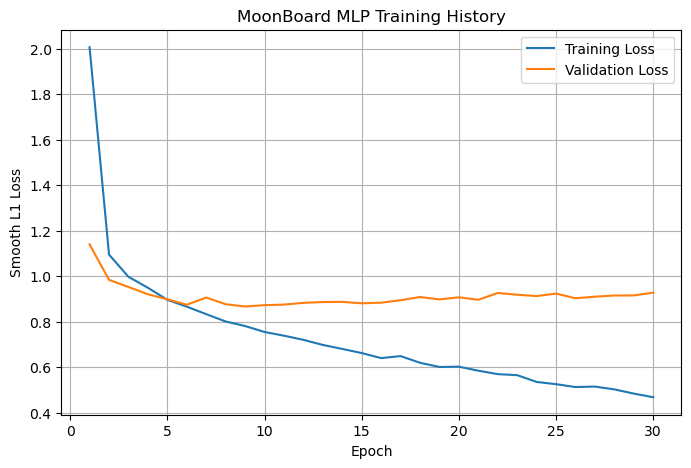

In [48]:
# Plot the learning curves

import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    training_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Smooth L1 Loss")
plt.title("MoonBoard MLP Training History")
plt.legend()
plt.grid(True)
plt.show()

In [49]:
# Find the best epoch

best_epoch = int(np.argmin(validation_losses)) + 1
best_validation_loss = min(validation_losses)

print("Best epoch:", best_epoch)
print("Lowest validation loss:", best_validation_loss)

Best epoch: 9
Lowest validation loss: 0.8668686900589917


## Train with Early Stopping

The model is retrained while monitoring validation loss. Whenever validation performance improves, the model's weights are saved. Training stops when validation loss has not improved for several consecutive epochs.

In [50]:
import copy

torch.manual_seed(42)

model = MoonBoardMLP().to(device)

criterion = nn.SmoothL1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

max_epochs = 50
patience = 6

training_losses = []
validation_losses = []

best_validation_loss = float("inf")
best_model_weights = None
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(max_epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()
    total_training_loss = 0.0

    for route_batch, grade_batch in train_loader:
        route_batch = route_batch.to(device)
        grade_batch = grade_batch.to(device)

        optimizer.zero_grad()

        predictions = model(route_batch)
        loss = criterion(predictions, grade_batch)

        loss.backward()
        optimizer.step()

        total_training_loss += loss.item()

    average_training_loss = (
        total_training_loss / len(train_loader)
    )

    # -------------------------
    # Validation
    # -------------------------
    model.eval()
    total_validation_loss = 0.0

    with torch.no_grad():
        for route_batch, grade_batch in val_loader:
            route_batch = route_batch.to(device)
            grade_batch = grade_batch.to(device)

            predictions = model(route_batch)
            loss = criterion(predictions, grade_batch)

            total_validation_loss += loss.item()

    average_validation_loss = (
        total_validation_loss / len(val_loader)
    )

    training_losses.append(average_training_loss)
    validation_losses.append(average_validation_loss)

    print(
        f"Epoch {epoch + 1:02d}/{max_epochs} | "
        f"Training Loss: {average_training_loss:.4f} | "
        f"Validation Loss: {average_validation_loss:.4f}"
    )

    # -------------------------
    # Save the best model
    # -------------------------
    if average_validation_loss < best_validation_loss:
        best_validation_loss = average_validation_loss
        best_epoch = epoch + 1

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    # -------------------------
    # Early stopping
    # -------------------------
    if epochs_without_improvement >= patience:
        print(
            f"\nEarly stopping after epoch {epoch + 1}."
        )
        break

Epoch 01/50 | Training Loss: 2.0058 | Validation Loss: 1.1397
Epoch 02/50 | Training Loss: 1.0950 | Validation Loss: 0.9839
Epoch 03/50 | Training Loss: 0.9973 | Validation Loss: 0.9527
Epoch 04/50 | Training Loss: 0.9492 | Validation Loss: 0.9208
Epoch 05/50 | Training Loss: 0.8963 | Validation Loss: 0.8984
Epoch 06/50 | Training Loss: 0.8662 | Validation Loss: 0.8747
Epoch 07/50 | Training Loss: 0.8333 | Validation Loss: 0.9062
Epoch 08/50 | Training Loss: 0.8011 | Validation Loss: 0.8769
Epoch 09/50 | Training Loss: 0.7812 | Validation Loss: 0.8669
Epoch 10/50 | Training Loss: 0.7549 | Validation Loss: 0.8729
Epoch 11/50 | Training Loss: 0.7387 | Validation Loss: 0.8752
Epoch 12/50 | Training Loss: 0.7206 | Validation Loss: 0.8829
Epoch 13/50 | Training Loss: 0.6981 | Validation Loss: 0.8863
Epoch 14/50 | Training Loss: 0.6806 | Validation Loss: 0.8873
Epoch 15/50 | Training Loss: 0.6624 | Validation Loss: 0.8809

Early stopping after epoch 15.


In [51]:
# Restore the best weights

model.load_state_dict(best_model_weights)

print("Best epoch:", best_epoch)
print("Best validation loss:", best_validation_loss)
print("Best model weights restored.")

Best epoch: 9
Best validation loss: 0.8668686900589917
Best model weights restored.


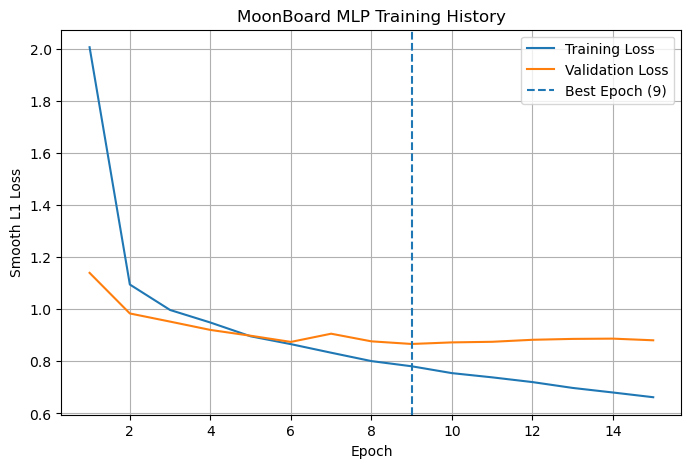

In [52]:
# Plot the new history

epochs = range(1, len(training_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    training_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_losses,
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Smooth L1 Loss")
plt.title("MoonBoard MLP Training History")
plt.legend()
plt.grid(True)
plt.show()

## Evaluate the Best Model

The model is evaluated on the untouched test set using regression and grade-based metrics. The best validation checkpoint is used rather than the final training checkpoint.

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model.eval()

test_predictions = []
test_actual = []

with torch.no_grad():
    for route_batch, grade_batch in test_loader:
        route_batch = route_batch.to(device)

        predictions = model(route_batch)

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_actual.extend(
            grade_batch.numpy()
        )

test_predictions = np.array(test_predictions)
test_actual = np.array(test_actual)

In [54]:
# Calculate the metrics

test_mae = mean_absolute_error(
    test_actual,
    test_predictions
)

test_rmse = np.sqrt(
    mean_squared_error(
        test_actual,
        test_predictions
    )
)

rounded_predictions = np.rint(test_predictions)

rounded_accuracy = np.mean(
    rounded_predictions == test_actual
)

within_one_grade_accuracy = np.mean(
    np.abs(rounded_predictions - test_actual) <= 1
)

print(f"Test MAE: {test_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Exact rounded-grade accuracy: {rounded_accuracy:.4f}")
print(f"Accuracy within one V-grade: {within_one_grade_accuracy:.4f}")

Test MAE: 1.2731
Test RMSE: 1.7434
Exact rounded-grade accuracy: 0.2973
Accuracy within one V-grade: 0.6678


In [55]:
# Inspect several predictions

for index in range(10):
    print(
        f"Route {index + 1}: "
        f"Predicted {test_predictions[index]:.2f} "
        f"(V{int(rounded_predictions[index])}) | "
        f"Actual V{int(test_actual[index])}"
    )

Route 1: Predicted 6.17 (V6) | Actual V4
Route 2: Predicted 5.72 (V6) | Actual V4
Route 3: Predicted 7.84 (V8) | Actual V7
Route 4: Predicted 6.96 (V7) | Actual V4
Route 5: Predicted 8.15 (V8) | Actual V8
Route 6: Predicted 6.50 (V7) | Actual V7
Route 7: Predicted 6.59 (V7) | Actual V5
Route 8: Predicted 9.06 (V9) | Actual V8
Route 9: Predicted 4.17 (V4) | Actual V4
Route 10: Predicted 3.64 (V4) | Actual V4


## Compare with the Gradient Boosting Baseline

A Gradient Boosting regressor is trained using the same cleaned dataset and identical training and test split as the PyTorch model. This allows the two models to be compared fairly.

In [56]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print("Gradient Boosting training shape:", X_train_flat.shape)
print("Gradient Boosting test shape:", X_test_flat.shape)

Gradient Boosting training shape: (9388, 198)
Gradient Boosting test shape: (1174, 198)


In [57]:
# Train the baseline

from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = GradientBoostingRegressor(
    random_state=42
)

gradient_boosting_model.fit(
    X_train_flat,
    y_train
)

# Evaluate it using the exact same metrics

gb_predictions = gradient_boosting_model.predict(
    X_test_flat
)

gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_predictions
    )
)

gb_rounded_predictions = np.rint(gb_predictions)

gb_rounded_accuracy = np.mean(
    gb_rounded_predictions == y_test
)

gb_within_one_accuracy = np.mean(
    np.abs(gb_rounded_predictions - y_test) <= 1
)

print(f"Gradient Boosting Test MAE: {gb_mae:.4f}")
print(f"Gradient Boosting Test RMSE: {gb_rmse:.4f}")
print(f"Gradient Boosting exact accuracy: {gb_rounded_accuracy:.4f}")
print(f"Gradient Boosting within-one accuracy: {gb_within_one_accuracy:.4f}")

Gradient Boosting Test MAE: 1.4593
Gradient Boosting Test RMSE: 1.8924
Gradient Boosting exact accuracy: 0.2232
Gradient Boosting within-one accuracy: 0.6065


In [58]:
# Create the comparison table

import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Gradient Boosting",
        "PyTorch MLP"
    ],
    "Test MAE": [
        gb_mae,
        test_mae
    ],
    "Test RMSE": [
        gb_rmse,
        test_rmse
    ],
    "Exact Grade Accuracy": [
        gb_rounded_accuracy,
        rounded_accuracy
    ],
    "Within One Grade": [
        gb_within_one_accuracy,
        within_one_grade_accuracy
    ]
})

comparison

,Model,Test MAE,Test RMSE,Exact Grade Accuracy,Within One Grade
0,Gradient Boosting,1.459288,1.892399,0.223169,0.606474
1,PyTorch MLP,1.273127,1.743353,0.297274,0.667802


## Save the Trained Model

The best PyTorch model checkpoint is saved along with the architecture settings and basic metadata required to reload it for future inference and deployment.

In [59]:
from pathlib import Path

model_directory = Path("../models/grade_predictor")
model_directory.mkdir(parents=True, exist_ok=True)

model_path = model_directory / "moonboard_mlp_v1.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_rows": 18,
        "input_columns": 11,
        "hidden_sizes": [128, 64, 32],
        "dropout": 0.20,
        "best_epoch": best_epoch,
        "best_validation_loss": best_validation_loss,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "exact_grade_accuracy": rounded_accuracy,
        "within_one_grade_accuracy": within_one_grade_accuracy,
        "model_version": "1.0.0"
    },
    model_path
)

print("Model saved to:", model_path)

Model saved to: ../models/grade_predictor/moonboard_mlp_v1.pt


In [60]:
# Reload the model into a fresh instance

checkpoint = torch.load(
    model_path,
    map_location=device,
)

loaded_model = MoonBoardMLP().to(device)

loaded_model.load_state_dict(
    checkpoint["model_state_dict"]
)

loaded_model.eval()

print("Loaded model version:", checkpoint["model_version"])
print("Loaded model test MAE:", checkpoint["test_mae"])
print("Model loaded successfully.")

Loaded model version: 1.0.0
Loaded model test MAE: 1.2731271
Model loaded successfully.


In [61]:
# Confirm identical predictions

route_batch, _ = next(iter(test_loader))
route_batch = route_batch.to(device)

model.eval()
loaded_model.eval()

with torch.no_grad():
    original_predictions = model(route_batch)
    loaded_predictions = loaded_model(route_batch)

predictions_match = torch.allclose(
    original_predictions,
    loaded_predictions
)

print("Predictions match:", predictions_match)

Predictions match: True


In [62]:
example_route_path = "../data/example_test_route.npy"

np.save(
    example_route_path,
    X_test[0]
)

print("Route saved to:", example_route_path)
print("Notebook prediction:", test_predictions[0])
print("Actual grade:", y_test[0])

Route saved to: ../data/example_test_route.npy
Notebook prediction: 6.1741242
Actual grade: 4.0


In [64]:
import json
import numpy as np

route = np.load("../data/example_test_route.npy")

request_body = {
    "holds": route.astype(int).tolist()
}

print(json.dumps(request_body, indent=2))

{
  "holds": [
    [
      0,
      0,
      0,
      0,
      1,
      0,
      0,
      0,
      0,
      0,
      0
    ],
    [
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0
    ],
    [
      0,
      0,
      0,
      1,
      0,
      0,
      1,
      0,
      0,
      0,
      0
    ],
    [
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0
    ],
    [
      0,
      0,
      1,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0
    ],
    [
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      1,
      0,
      0,
      0
    ],
    [
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0
    ],
    [
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0
    ],
    [
      0,
      0,
      1,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
 